<a href="https://colab.research.google.com/github/Shayantan1012/DeepLearning-Projects/blob/main/Speech_Emotion_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

In [3]:
paths=[]
labels=[]
for dirname, _, filenames in os.walk('/content/drive/MyDrive/XAI /Other data/TESS Toronto emotional speech set data'):
    for filename in filenames:
        paths.append(os.path.join(dirname, filename))
        label=filename.split('_')[-1]
        label=label.split('.')[0]
        labels.append(label.lower())


print("Dataset is Loaded!!!")


Dataset is Loaded!!!


In [4]:
paths[:5]

['/content/drive/MyDrive/XAI /Other data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/OAF_Fear/OAF_back_fear.wav',
 '/content/drive/MyDrive/XAI /Other data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/OAF_Fear/OAF_boat_fear.wav',
 '/content/drive/MyDrive/XAI /Other data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/OAF_Fear/OAF_beg_fear.wav',
 '/content/drive/MyDrive/XAI /Other data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/OAF_Fear/OAF_bath_fear.wav',
 '/content/drive/MyDrive/XAI /Other data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/OAF_Fear/OAF_base_fear.wav']

In [5]:
df=pd.DataFrame()
df['speech']=paths
df['label']=labels
df.head()

,speech,label
0,/content/drive/MyDrive/XAI /Other data/TESS To...,fear
1,/content/drive/MyDrive/XAI /Other data/TESS To...,fear
2,/content/drive/MyDrive/XAI /Other data/TESS To...,fear
3,/content/drive/MyDrive/XAI /Other data/TESS To...,fear
4,/content/drive/MyDrive/XAI /Other data/TESS To...,fear


In [6]:
df['label'].value_counts()

,count
label,
fear,800
angry,800
disgust,800
neutral,800
happy,800
ps,800
sad,800


<Axes: xlabel='count', ylabel='label'>

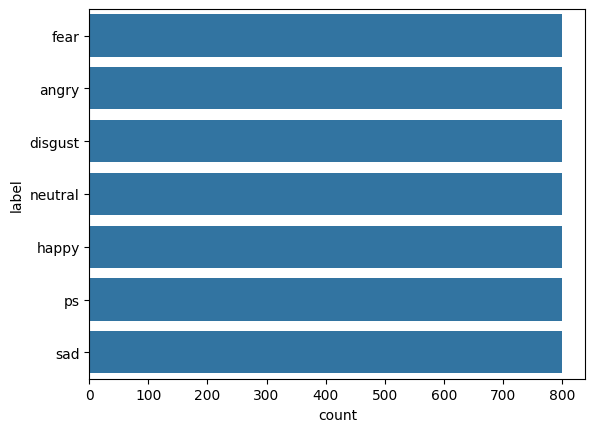

In [7]:
sns.countplot(df['label'])

In [8]:
def waveplot(data,sr,emotion):
  plt.figure(figsize=(10,4))
  plt.title(emotion,size=20)
  librosa.display.waveshow(data,sr=sr)
  plt.show()

def spectogram(data,sr,emotion):
  x=librosa.stft(data)
  xdb=librosa.amplitude_to_db(abs(x))
  plt.figure(figsize=(10,4))
  plt.title(emotion,size=20)
  librosa.display.specshow(xdb, sr=sr, x_axis='time', y_axis='hz')
  plt.colorbar()


In [9]:
df['speech'][0]

'/content/drive/MyDrive/XAI /Other data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/OAF_Fear/OAF_back_fear.wav'

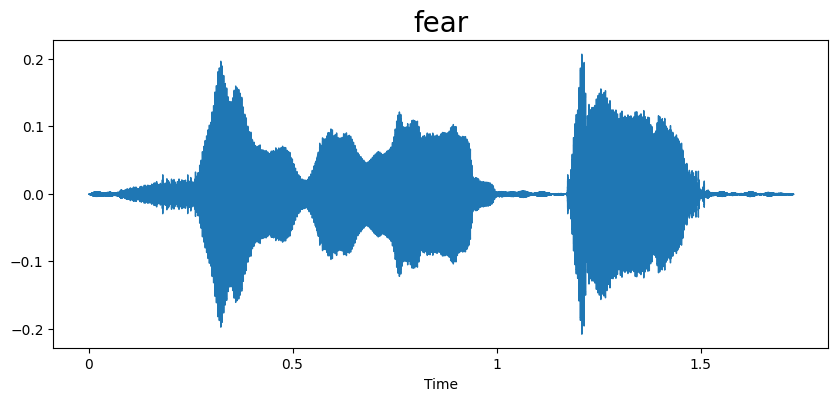

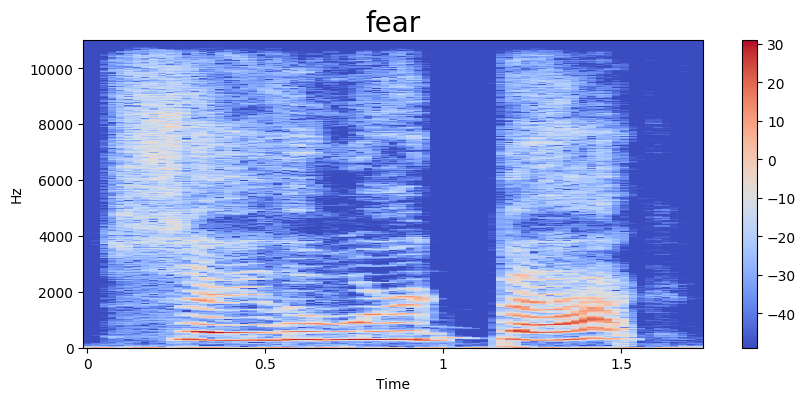

In [10]:
emotion ='fear'
path=df['speech'][df['label']==emotion][0]
data, sampling_rate = librosa.load(path)  # Use path directly
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(data,rate=sampling_rate)

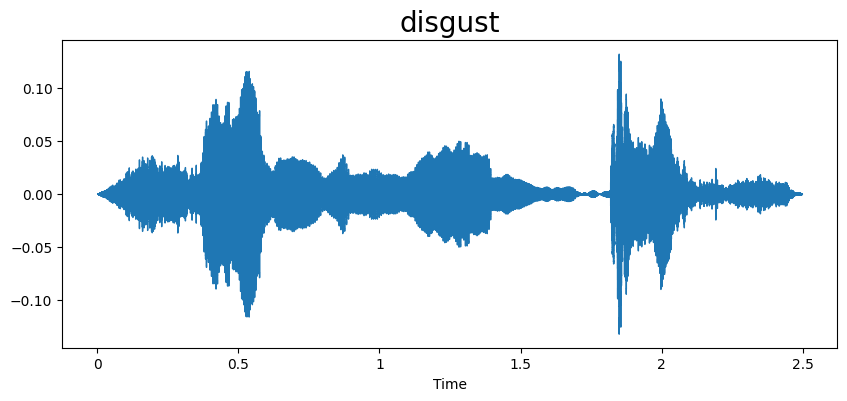

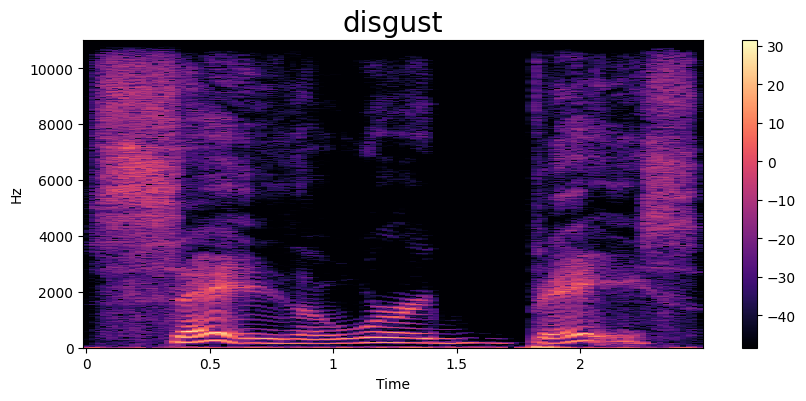

In [11]:
emotion ='disgust'
path=np.array(df['speech'][df['label']==emotion])[1]
data, sampling_rate = librosa.load(path)  # Use path directly
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(data,rate=sampling_rate)

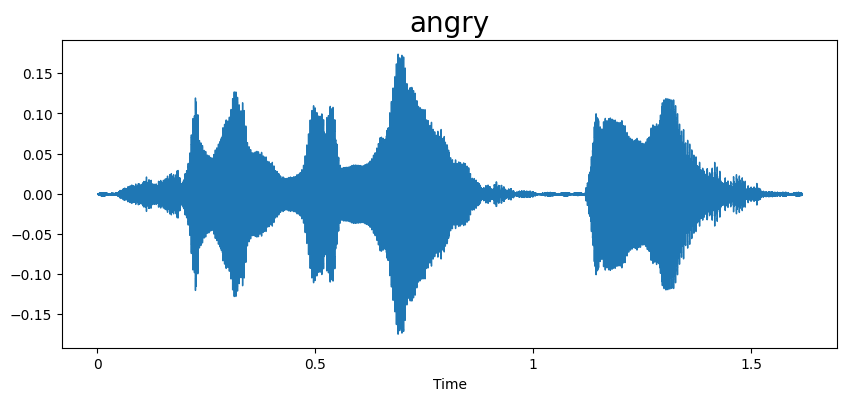

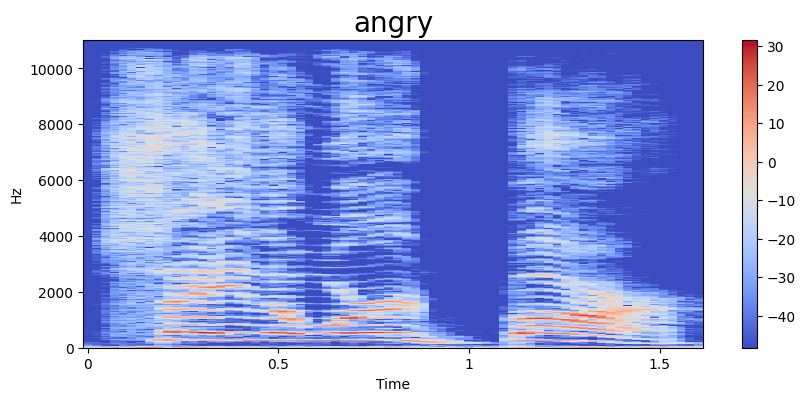

In [12]:
emotion ='angry'
path=np.array(df['speech'][df['label']==emotion])[0]

data, sampling_rate = librosa.load(path)  # Use path directly
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(data,rate=sampling_rate)

In [13]:
def extract_mfcc(filename):
  y,sr=librosa.load(filename,duration=3,offset=0.5)
  mfcc=np.mean(librosa.feature.mfcc(y=y,sr=sr,n_mfcc=40).T,axis=0)
  return mfcc

In [14]:
X_mfcc=df['speech'].apply(lambda x: extract_mfcc(x))

In [15]:
X_mfcc

,speech
0,"[-445.36737, 91.2761, -0.58949184, -17.314266,..."
1,"[-500.6967, 90.146454, 24.972002, -9.280767, -..."
2,"[-434.80698, 72.62281, 7.8739104, -9.481151, 1..."
3,"[-412.7426, 85.44517, 7.658597, -21.482409, -0..."
4,"[-461.2538, 56.51359, 13.970672, 2.563786, 8.1..."
...,...
5595,"[-331.54327, 43.91221, 0.11755641, 8.831392, -..."
5596,"[-304.33426, 55.774597, -13.109112, 6.8744235,..."
5597,"[-341.12894, 29.925764, -1.8319321, -2.1546454..."
5598,"[-325.60358, 54.542873, -19.791151, -2.9493518..."


In [25]:
X=np.expand_dims(X_mfcc,-1);
X.shape

(5600, 1)

In [42]:
from sklearn.preprocessing import OneHotEncoder
enc=OneHotEncoder()
y=enc.fit_transform(df[['label']])
y


<5600x7 sparse matrix of type '<class 'numpy.float64'>'
	with 5600 stored elements in Compressed Sparse Row format>

In [34]:
X=[x for x in X_mfcc]
X=np.array(X)
X.shape

(5600, 40)

In [35]:
X=np.expand_dims(X,-1)
(X.dtype)

dtype('float32')

# Build LSTM *Model*

In [46]:
from keras.models import Sequential
from keras.layers import Dense,LSTM,Dropout

model=Sequential()
model.add(LSTM(123,input_shape=(40,1),return_sequences=False))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(7,activation='softmax'))
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()
model.save('model.h5')

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 123)                 │          61,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           7,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,747 (280.26 KB)

 Trainable params: 71,747 (280.26 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# X=np.array(X)
# y=np.array(y.toarray())
history = model.fit(X, y, validation_split=0.2, epochs=50, batch_size=64)


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9837 - loss: 0.0534 - val_accuracy: 0.9991 - val_loss: 0.0079
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.9934 - loss: 0.0227 - val_accuracy: 0.9955 - val_loss: 0.0082
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9974 - loss: 0.0111 - val_accuracy: 0.9973 - val_loss: 0.0095
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.9965 - loss: 0.0120 - val_accuracy: 1.0000 - val_loss: 5.2988e-04
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.9996 - loss: 0.0021 - val_accuracy: 0.9937 - val_loss: 0.0307
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.9985 - loss: 0.0052 - val_accuracy: 0.9955 - val_loss: 0.0116
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.9934 - loss: 0.0219 - val_accuracy: 0.9982 - val_loss: 0.0055
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9982 - loss: 0.0086 - val_accuracy: 0.9804

In [52]:
model.save('BestModelForSpeechImotionDetection.h5')

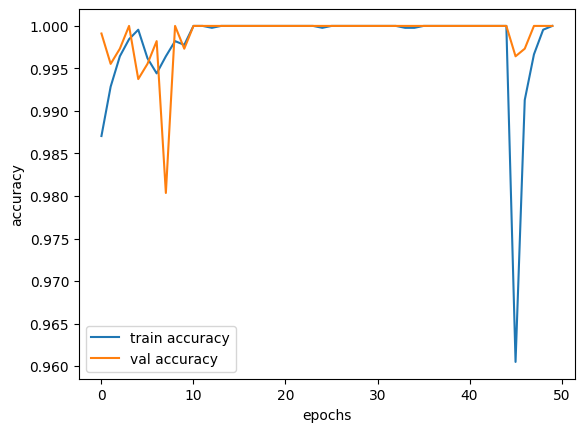

In [53]:
epochs = list(range(50))
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, label='train accuracy')
plt.plot(epochs, val_acc, label='val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

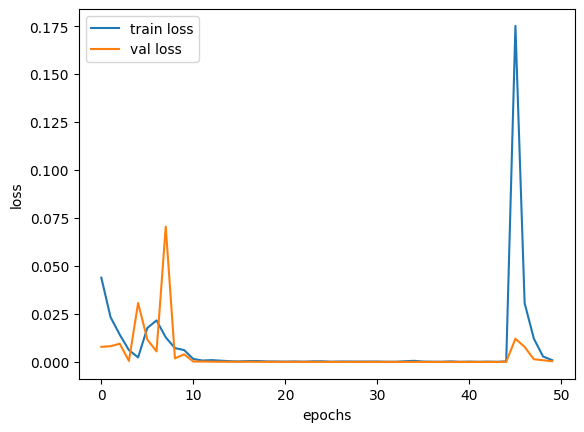

In [51]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, label='train loss')
plt.plot(epochs, val_loss, label='val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

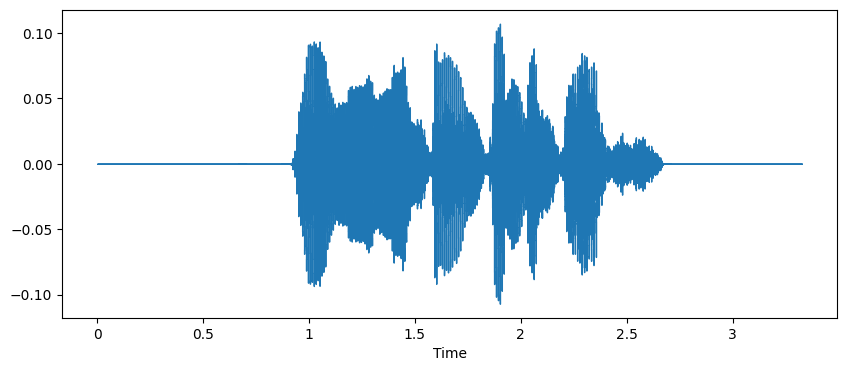

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
fear


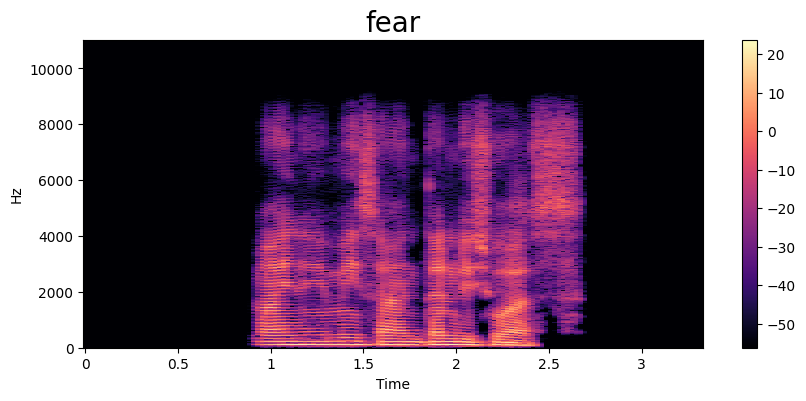

In [56]:
test_path='/content/drive/MyDrive/XAI /Other data/TestSpeech.m4a'
x_test=extract_mfcc(test_path)
data, sampling_rate = librosa.load(test_path)

plt.figure(figsize=(10,4))
librosa.display.waveshow(data,sr=sampling_rate)
plt.show()

x=librosa.stft(data)
xdb=librosa.amplitude_to_db(abs(x))
plt.figure(figsize=(10,4))

y=model.predict(np.expand_dims(x_test,-1))
emotion=enc.inverse_transform(y)[0][0]
print(emotion)
plt.title(emotion,size=20)
librosa.display.specshow(xdb, sr=sampling_rate, x_axis='time', y_axis='hz')
plt.colorbar()
Audio(data,rate=sampling_rate)

